# 00 -- UCI HAR: данные, EDA и stress-test

Использую тот же UCI HAR, чтобы сравнение с предыдущими ДЗ оставалось понятным.

Кроме чистого корпуса добавляю отдельный **block-corruption stress-test**. Он не заменяет основной эксперимент: модели по-прежнему обучаются на чистых данных, а затем проверяются при частичной потере временных участков.

In [19]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA = ROOT / 'data'
FIG = ROOT / 'figures'
RESULTS = ROOT / 'results'
for p in [DATA, FIG, RESULTS]:
    p.mkdir(exist_ok=True)

SEED = 42
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = DATA / 'uci_har.zip'


In [20]:
if not ZIP_PATH.exists():
    urlretrieve(URL, ZIP_PATH)

extract_dir = DATA / 'uci_har_src'
outer_done = extract_dir / '.outer_done'
if not outer_done.exists():
    extract_dir.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(extract_dir)
    outer_done.touch()

inner_zip = extract_dir / 'UCI HAR Dataset.zip'
if inner_zip.exists() and not (extract_dir / 'UCI HAR Dataset').exists():
    with zipfile.ZipFile(inner_zip) as zf:
        zf.extractall(extract_dir)

base = extract_dir / 'UCI HAR Dataset'
base


PosixPath('/Users/dvsorochan/hse/hws/t5/dl/data/uci_har_src/UCI HAR Dataset')

In [21]:
SIGNALS = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]

CLASSES = [
    'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
    'SITTING', 'STANDING', 'LAYING'
]

def load_split(split):
    signal_dir = base / split / 'Inertial Signals'
    X = np.stack([
        np.loadtxt(signal_dir / f'{name}_{split}.txt', dtype=np.float32)
        for name in SIGNALS
    ], axis=1)
    y = np.loadtxt(base / split / f'y_{split}.txt', dtype=int) - 1
    subject = np.loadtxt(base / split / f'subject_{split}.txt', dtype=int)
    return X, y, subject

X_train, y_train, subject_train = load_split('train')
X_test, y_test, subject_test = load_split('test')

np.savez_compressed(
    DATA / 'uci_har_raw.npz',
    X_train=X_train, y_train=y_train, subject_train=subject_train,
    X_test=X_test, y_test=y_test, subject_test=subject_test,
)

print('train:', X_train.shape, 'test:', X_test.shape)
print('classes:', len(np.unique(y_train)))
print('train subjects:', len(np.unique(subject_train)), 'test subjects:', len(np.unique(subject_test)))


train: (7352, 9, 128) test: (2947, 9, 128)
classes: 6
train subjects: 21 test subjects: 9


In [22]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=SEED)
train_idx, val_idx = next(splitter.split(X_train, y_train, groups=subject_train))

np.savez(DATA / 'split.npz', train_idx=train_idx, val_idx=val_idx)

print('fit:', len(train_idx), 'val:', len(val_idx))
print('fit subjects:', sorted(np.unique(subject_train[train_idx])))
print('val subjects:', sorted(np.unique(subject_train[val_idx])))
print('subject overlap:', np.intersect1d(subject_train[train_idx], subject_train[val_idx]))


fit: 5551 val: 1801
fit subjects: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(28), np.int64(29), np.int64(30)]
val subjects: [np.int64(1), np.int64(3), np.int64(15), np.int64(25), np.int64(27)]
subject overlap: []


## Баланс классов

Классы достаточно сбалансированы, поэтому accuracy остается понятной общей метрикой. Для выбора конфигураций и robustness-сравнений основной метрикой использую **macro F1**: он одинаково учитывает все 6 классов и не позволяет хорошему качеству на простом классе скрыть просадку на более сложном.


In [23]:
counts = pd.DataFrame({
    'class': CLASSES,
    'train': np.bincount(y_train, minlength=6),
    'test': np.bincount(y_test, minlength=6),
})
counts


,class,train,test
0,WALKING,1226,496
1,WALKING_UPSTAIRS,1073,471
2,WALKING_DOWNSTAIRS,986,420
3,SITTING,1286,491
4,STANDING,1374,532
5,LAYING,1407,537


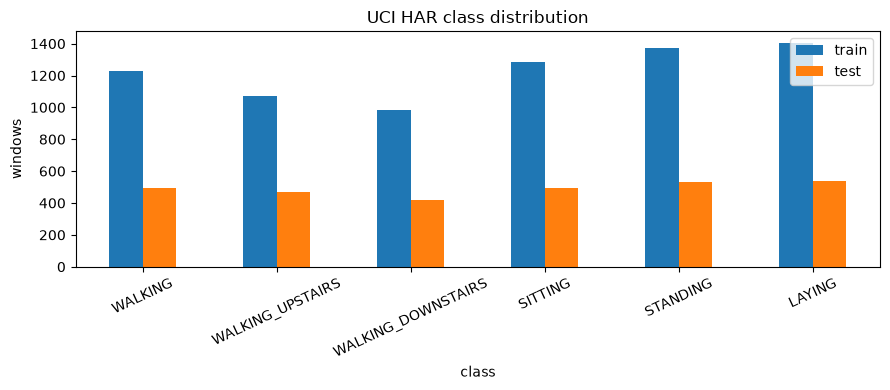

In [24]:
ax = counts.set_index('class').plot(kind='bar', figsize=(9, 4), rot=25)
ax.set_ylabel('windows')
ax.set_title('UCI HAR class distribution')
plt.tight_layout()
plt.savefig(FIG / '00_class_distribution.png', dpi=160)
plt.show()


## Примеры сигналов

Показываю три оси `body_acc` для одного окна каждого класса. Динамические активности визуально имеют более выраженную периодику; `SITTING` / `STANDING` ближе друг к другу.


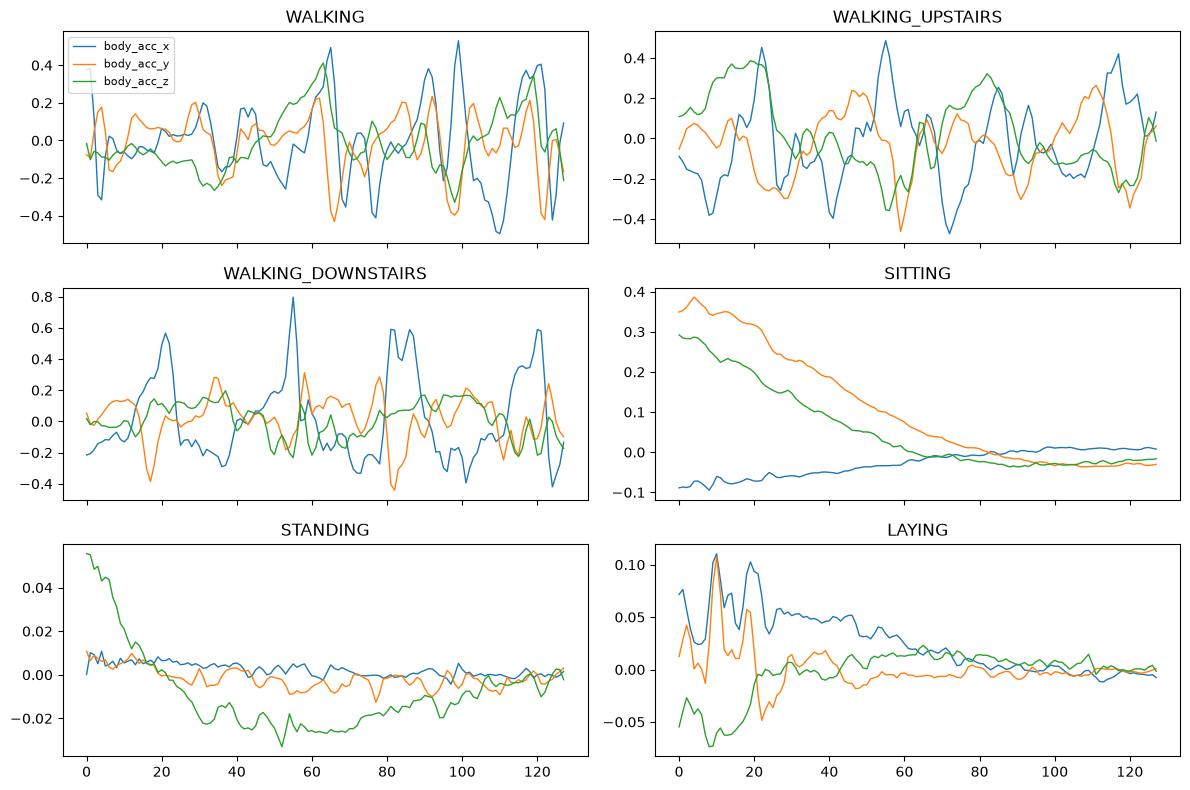

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for cls, ax in enumerate(axes.ravel()):
    i = np.flatnonzero(y_train == cls)[0]
    for ch in range(3):
        ax.plot(X_train[i, ch], label=SIGNALS[ch], linewidth=1)
    ax.set_title(CLASSES[cls])
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / '00_examples.png', dpi=160)
plt.show()


## Stress-test: блочная потеря информации

По аналогии с ДЗ 2 моделирую локальный отказ части каналов: у `4` из `9` каналов один непрерывный блок заменяется средним по **оставшейся наблюдаемой части** этого канала.

Использую уровни `0%`, `20%`, `35%`, `50%` длины окна. Это не настоящая missing-aware постановка: ни Transformer, ни Mantis не получают mask, а NaN в модель не подаются. Такой corruption просто удаляет часть локальной динамики и позволяет проверить устойчивость representations к ухудшению входа.

Seed фиксирован, поэтому для одинакового corruption level модели сравниваются на одной и той же детерминированной схеме порчи.


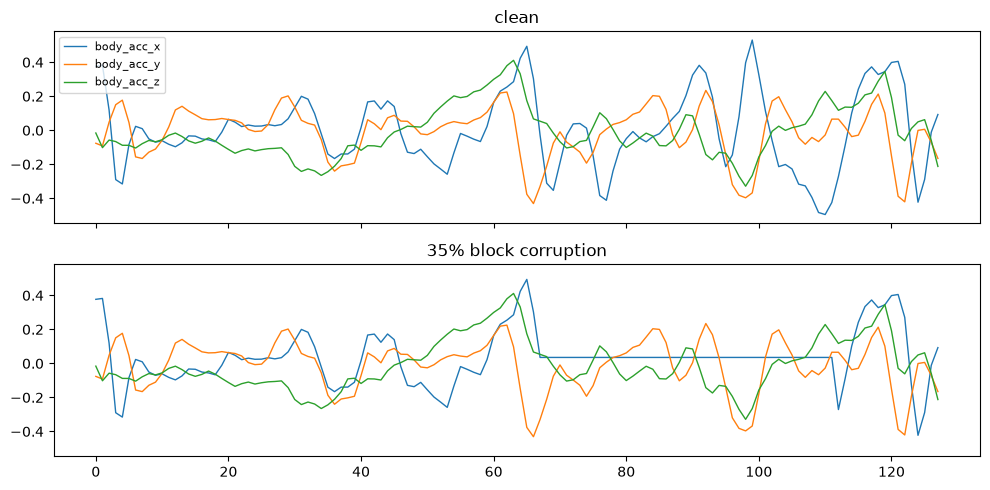

In [26]:
def block_corrupt(X, fraction=0.35, n_channels=4, seed=SEED):
    Xc = X.copy()
    if fraction == 0:
        return Xc

    rng = np.random.default_rng(seed)
    _, channels, length = Xc.shape
    width = max(1, int(round(length * fraction)))

    for i in range(len(Xc)):
        selected = rng.choice(channels, size=n_channels, replace=False)
        center = int(rng.integers(0, length))
        start = min(max(center - width // 2, 0), length - width)
        observed = np.ones(length, dtype=bool)
        observed[start:start + width] = False

        for ch in selected:
            fill = Xc[i, ch, observed].mean()
            Xc[i, ch, start:start + width] = fill

    return Xc

# Один пример: clean vs 35% block corruption.
i = np.flatnonzero(y_train == 0)[0]
demo = block_corrupt(X_train[[i]], fraction=0.35, n_channels=4, seed=SEED)[0]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)
for ch in range(3):
    axes[0].plot(X_train[i, ch], linewidth=1, label=SIGNALS[ch])
    axes[1].plot(demo[ch], linewidth=1, label=SIGNALS[ch])
axes[0].set_title('clean')
axes[1].set_title('35% block corruption')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / '00_corruption_example.png', dpi=160)
plt.show()

## Связи каналов

Для компактного EDA усредняю каждое окно по времени и считаю корреляции между 9 каналами.


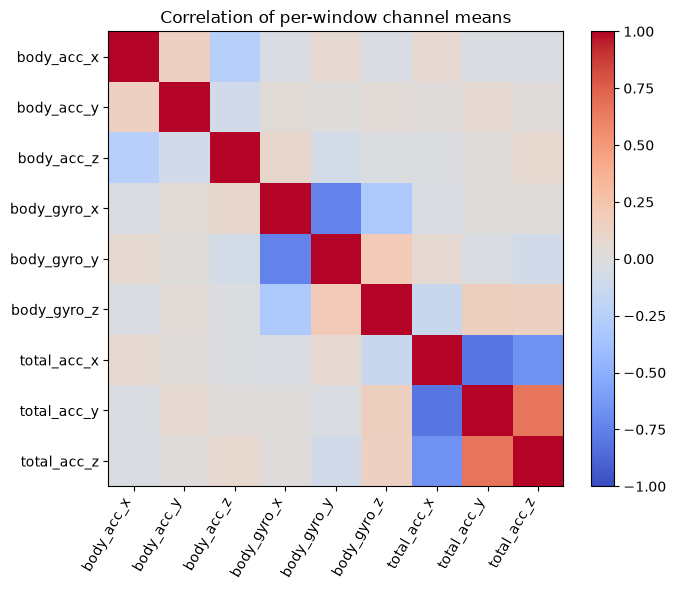

In [27]:
channel_means = X_train.mean(axis=2)
corr = np.corrcoef(channel_means, rowvar=False)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(9), SIGNALS, rotation=60, ha='right')
ax.set_yticks(range(9), SIGNALS)
ax.set_title('Correlation of per-window channel means')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG / '00_channel_correlation.png', dpi=160)
plt.show()


## Итог

Получаем `7352` train и `2947` test окон формы `9 x 128`. Official split разделен по людям; validation также выделена внутри train group-wise по `subject_id`, поэтому одинаковый человек не попадает одновременно в fit и validation.

Основной эксперимент остается обычной классификацией clean UCI HAR. Stress-test отвечает на дополнительный вопрос: насколько преимущество pretrained Mantis-признаков сохраняется, когда часть временной информации искусственно уничтожена.


### Что важно дальше

Clean test нужен для основного сравнения качества. Corrupted test используется только в самом конце и не участвует в выборе эпох, слоя или scale. Для выбора Mantis-конфигурации используются только clean/corrupted **validation** данные.